EJERCICIO N1

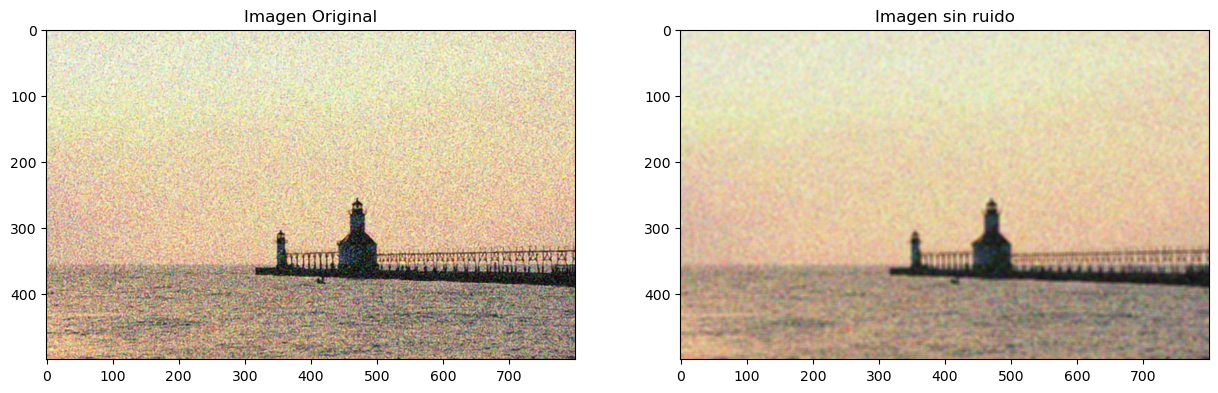

In [39]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def convMediaHor(imagen, tamanioK):
    kernel = np.ones((1, tamanioK), np.float32) / tamanioK
    kernel2 = np.ones((tamanioK, 1), np.float32) / tamanioK
    imgFin = cv2.filter2D(imagen, -1, kernel)
    imgFin = cv2.filter2D(imgFin, -1, kernel2)
    return imgFin

imagen = cv2.imread("ruido.jpg")

gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

img = convMediaHor(gris, 6)

plt.figure(figsize=(15, 10))
plt.subplot(1,2,1)
plt.title("Imagen Original")
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))

plt.subplot(1,2,2)
plt.title("Imagen sin ruido")
plt.imshow(img)
plt.show()

EJERCICIO N2

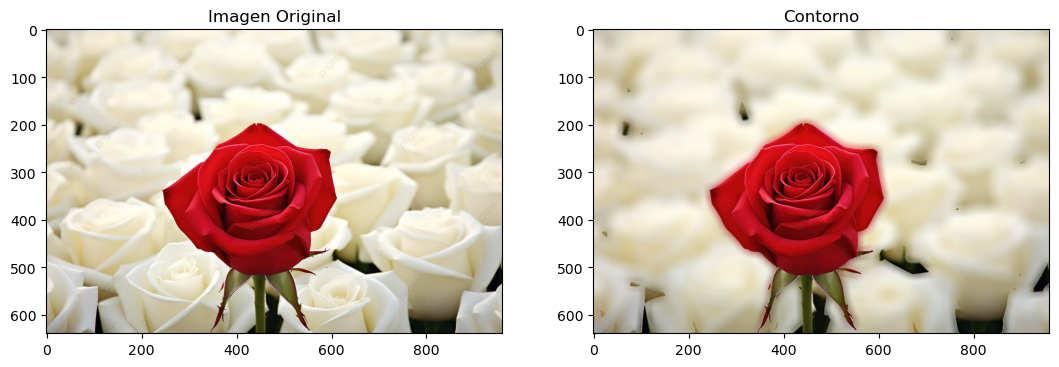

In [80]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('rosa.png')
gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7, 7), 0)

_, binarized = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
contorno, _ = cv2.findContours(binarized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

mask = np.zeros_like(gray)
cv2.drawContours(mask, contorno, -1, 255, -1)
rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

def convMediaHor(imagen, tamanioK):
    kernel = np.ones((1, tamanioK), np.float32) / tamanioK
    kernel2 = np.ones((tamanioK, 1), np.float32) / tamanioK
    imgFin = cv2.filter2D(imagen, -1, kernel)
    imgFin = cv2.filter2D(imgFin, -1, kernel2)
    return imgFin

suavizada = convMediaHor(rgb,30)

mascara = cv2.merge([mask, mask, mask])
resultado = np.where(mascara == 255, rgb, suavizada)

lines = cv2.drawContours(np.zeros_like(gray), contorno, -1, 255, 2)

plt.figure(figsize=(20, 15))
plt.subplot(131)
plt.title('Imagen Original')
plt.imshow(rgb)

plt.subplot(132)
plt.title('Contorno')
plt.imshow(resultado)
plt.show()


EJERCICIO N3

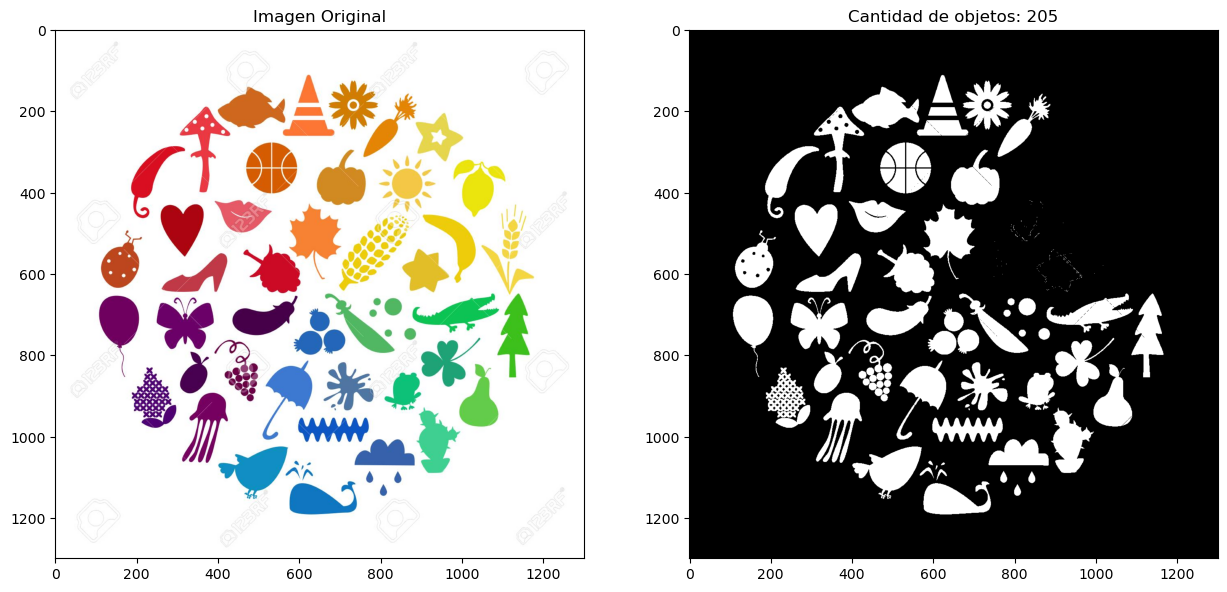

In [110]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def contar2(img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, img_bin = cv2.threshold(img_gray, 178, 255, cv2.THRESH_BINARY_INV)
    contorno = measure.label(img_bin, connectivity=2)
    num = np.max(contorno)
    return num, img_bin

imagen = cv2.imread('elementos.jpg')
num, img_bin = contar2(imagen)

plt.figure(figsize=(15, 10))
plt.subplot(1,2,1)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))

plt.subplot(1,2,2)
plt.title(f'Cantidad de objetos: {num}')
plt.imshow(img_bin, cmap='gray')
plt.show()

EJERCICIO N4

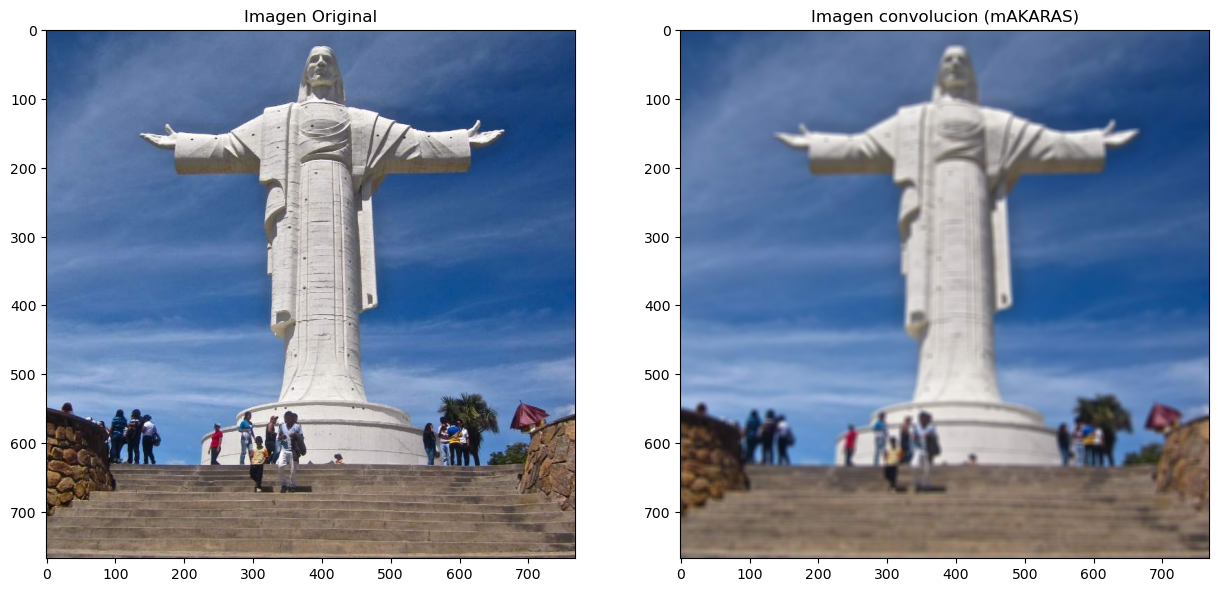

In [60]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def convMediaHor(imagen, tamanioK):
    kernel = np.ones((1, tamanioK), np.float32) / tamanioK
    kernel2 = np.ones((tamanioK, 1), np.float32) / tamanioK
    imgFin = cv2.filter2D(imagen, -1, kernel)
    imgFin = cv2.filter2D(imgFin, -1, kernel2)
    return imgFin

imagen = cv2.imread("cristo.jpg")

gris = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

img = convMediaHor(gris, 8)

plt.figure(figsize=(15, 10))
plt.subplot(1,2,1)
plt.title("Imagen Original")
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))

plt.subplot(1,2,2)
plt.title("Imagen convolucion (mAKARAS)")
plt.imshow(img)
plt.show()

EJERCICIO N5

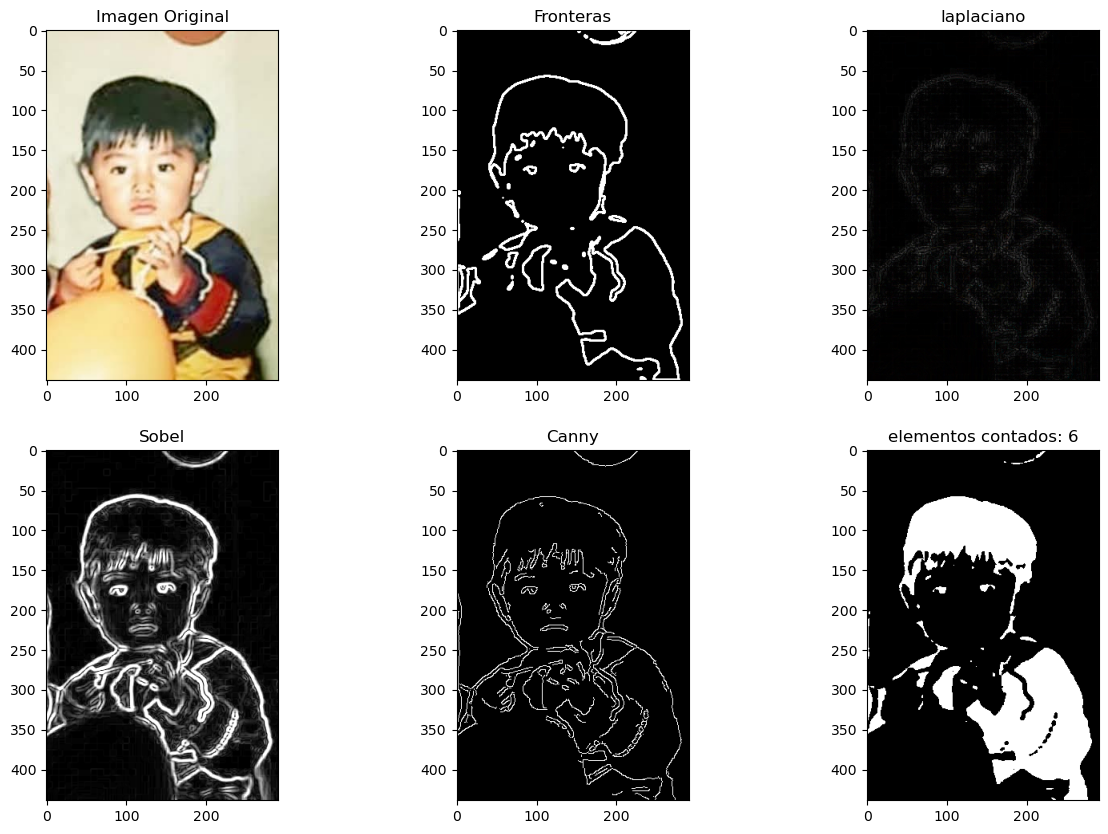

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_laplace

imagen = cv2.imread('yo.jpeg')
gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7, 7), 0)
#laplaciano
_, binarized = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
laplaciano = cv2.Laplacian(img, cv2.CV_64F)
laplaciano = cv2.convertScaleAbs(laplaciano)
#relleno
def conteo(img):
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    _, binaria = cv2.threshold(img_gray, 127, 255, cv2.THRESH_BINARY_INV)
    contornos, _ = cv2.findContours(binaria, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    cont = len(contornos[0])
    return cont, binaria
img_cont, bin = conteo(imagen)
#Fronteras
contorno, _ = cv2.findContours(binarized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
lines = cv2.drawContours(np.zeros_like(gray), contorno, -1, 255, 2)
# Sobel 


sobelx = cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3)
sobely = cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3)
sobel = cv2.magnitude(sobelx, sobely)
sobel = cv2.convertScaleAbs(sobel)

# Canny
canny = cv2.Canny(gray, 100, 200)

#Mostrar imagenes
plt.figure(figsize=(15, 10))
plt.subplot(231)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))

plt.subplot(232)
plt.title('Fronteras')
plt.imshow(lines, cmap='gray')

plt.subplot(233)
plt.title('laplaciano')
plt.imshow(laplaciano, cmap='gray')

plt.subplot(234)
plt.title('Sobel')
plt.imshow(sobel, cmap='gray')

plt.subplot(235)
plt.title('Canny')
plt.imshow(canny, cmap='gray')

plt.subplot(236)
plt.title(f'elementos contados: {img_cont}')
plt.imshow(bin, cmap='gray')

plt.show()


LAPLACIANO
Calcula la segunda derivada de la imagen. Detecta cambios abruptos de intensidad

SOBEL	Calcula la primera derivada en X e Y. Puede orientarse a direcciones específicas

CANNY	Algoritmo más avanzado. Usa suavizado, gradiente, supresión no máxima y umbrales dobles.


CONTORNOS Detecta objetos cerrados en una imagen binarizada

FRONTERAS buena para la deteccion rapido de los bordes

EJERCICIO N6

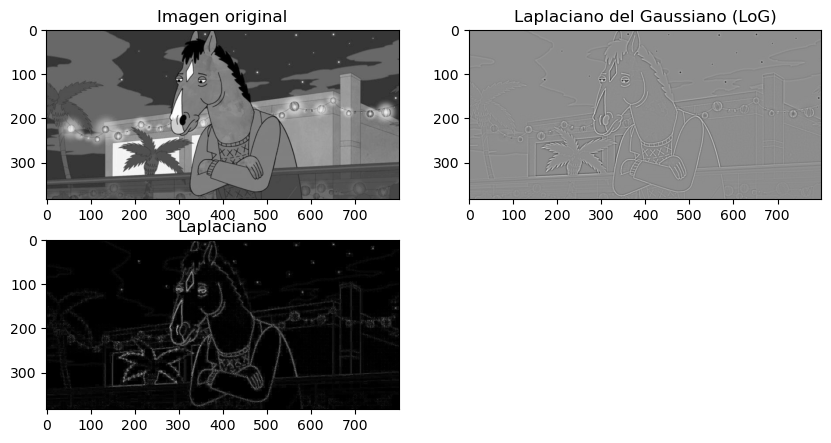

In [95]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_laplace

imagen = cv2.imread('cawallo.jpeg', cv2.IMREAD_GRAYSCALE)
laplaciano = cv2.Laplacian(imagen, cv2.CV_64F)
laplaciano = cv2.convertScaleAbs(laplaciano)

img = imagen.astype(np.float32) / 255.0
resultante = gaussian_laplace(img, sigma=1.0)
ajustado = cv2.normalize(resultante, None, 0, 255, cv2.NORM_MINMAX)
res = ajustado.astype(np.uint8)

plt.figure(figsize=(10,5))

plt.subplot(2, 2, 1)
plt.title('Imagen original')
plt.imshow(imagen, cmap='gray')

plt.subplot(2, 2, 3)
plt.title('Laplaciano')
plt.imshow(laplaciano, cmap='gray')

plt.subplot(2, 2, 2)
plt.title('Laplaciano del Gaussiano (LoG)')
plt.imshow(res, cmap='gray')

plt.show()



PRUEBAS 

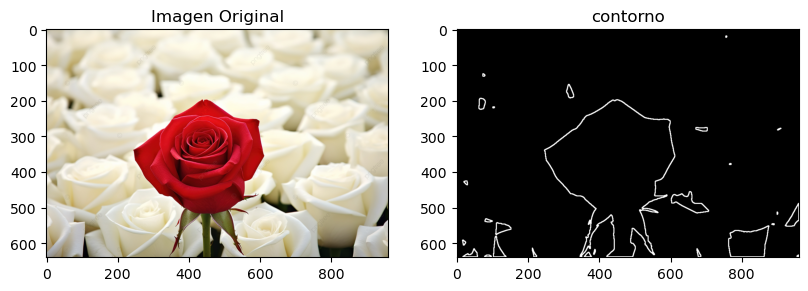

In [47]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('rosa.png')
gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7, 7), 0)

#primer codigo

_, binarized = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)

#Fronteras
contorno, _ = cv2.findContours(binarized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
lines = cv2.drawContours(np.zeros_like(gray), contorno, -1, 255, 2)

#Mostrar imagenes
plt.figure(figsize=(15, 5))
plt.subplot(131)
plt.title('Imagen Original')
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))


plt.subplot(132)
plt.title('contorno')
plt.imshow(lines, cmap='gray')
plt.show()





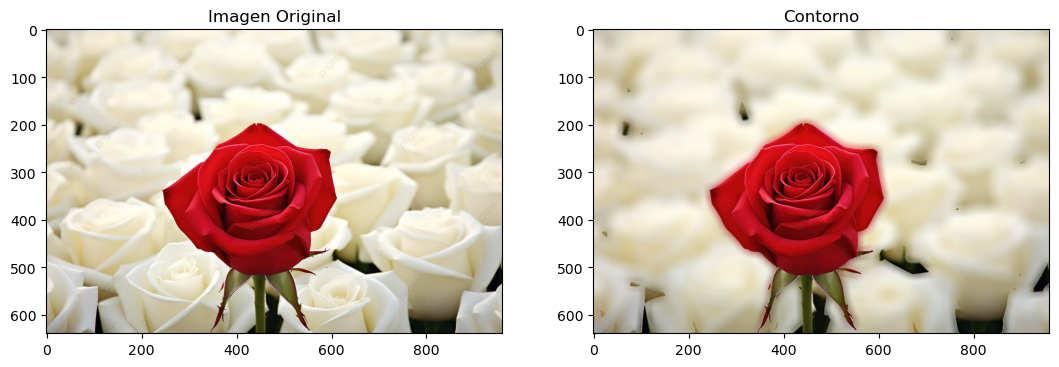

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

imagen = cv2.imread('rosa.png')
gray = cv2.cvtColor(imagen, cv2.COLOR_BGR2GRAY)
blur = cv2.GaussianBlur(gray, (7, 7), 0)

_, binarized = cv2.threshold(blur, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
contorno, _ = cv2.findContours(binarized, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

mask = np.zeros_like(gray)
cv2.drawContours(mask, contorno, -1, 255, -1)
rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

def convMediaHor(imagen, tamanioK):
    kernel = np.ones((1, tamanioK), np.float32) / tamanioK
    kernel2 = np.ones((tamanioK, 1), np.float32) / tamanioK
    imgFin = cv2.filter2D(imagen, -1, kernel)
    imgFin = cv2.filter2D(imgFin, -1, kernel2)
    return imgFin

suavizada = convMediaHor(rgb,30)

mascara = cv2.merge([mask, mask, mask])
resultado = np.where(mascara == 255, rgb, suavizada)

lines = cv2.drawContours(np.zeros_like(gray), contorno, -1, 255, 2)

plt.figure(figsize=(20, 15))
plt.subplot(131)
plt.title('Imagen Original')
plt.imshow(rgb)

plt.subplot(132)
plt.title('Contorno')
plt.imshow(resultado)
plt.show()


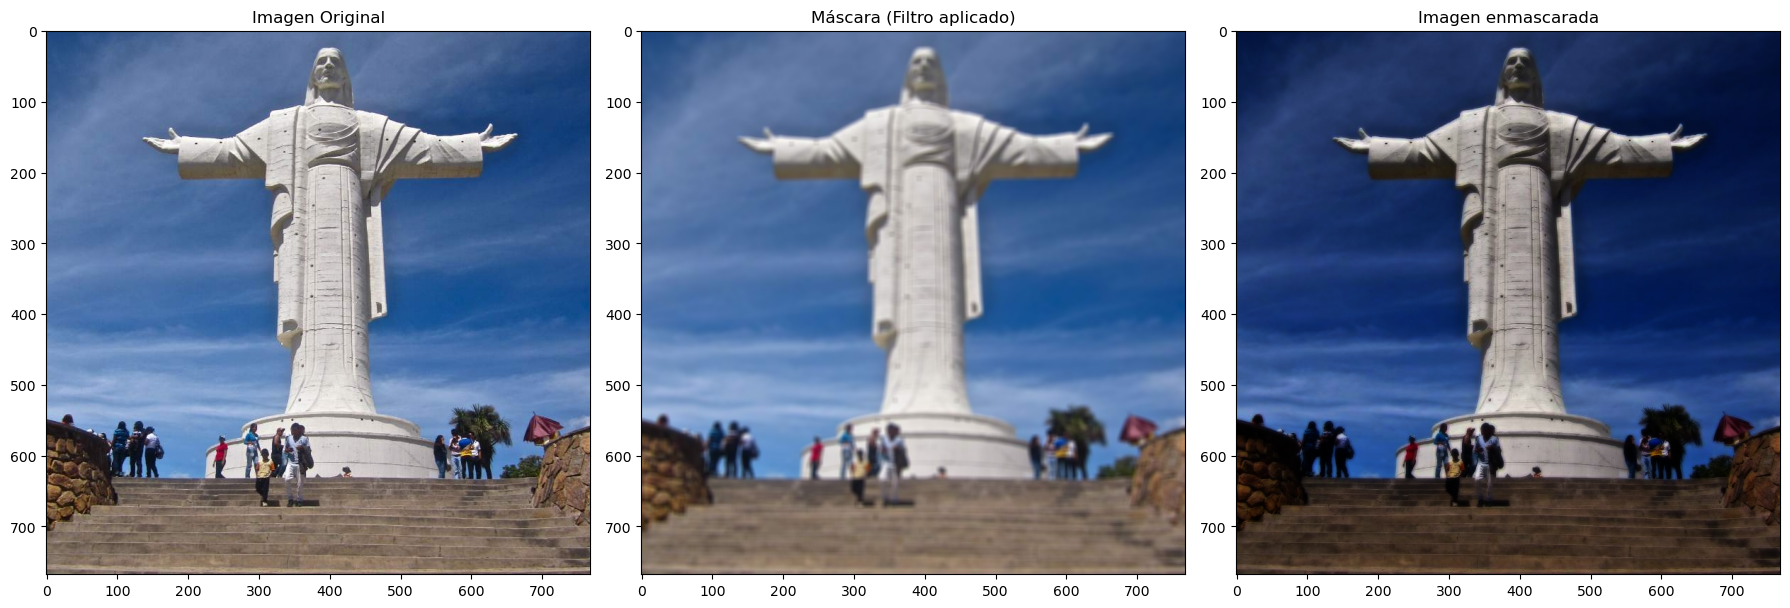

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def convMediaHor(imagen, tamanioK):
    kernel = np.ones((1, tamanioK), np.float32) / tamanioK
    kernel2 = np.ones((tamanioK, 1), np.float32) / tamanioK
    imgFin = cv2.filter2D(imagen, -1, kernel)
    imgFin = cv2.filter2D(imgFin, -1, kernel2)
    return imgFin

imagen = cv2.imread("cristo.jpg")
imagen_rgb = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)
img_mask = convMediaHor(imagen_rgb, 8)

img_mask_normalized = img_mask.astype(np.float32) / 255.0
imagen_float = imagen_rgb.astype(np.float32) / 255.0

resultado = cv2.multiply(imagen_float, img_mask_normalized)

resultado_uint8 = (resultado * 255).astype(np.uint8)

plt.figure(figsize=(18, 10))
plt.subplot(1, 3, 1)
plt.title("Imagen Original")
plt.imshow(imagen_rgb)

plt.subplot(1, 3, 2)
plt.title("Máscara (Filtro aplicado)")
plt.imshow(img_mask)

plt.subplot(1, 3, 3)
plt.title("Imagen enmascarada")
plt.imshow(resultado_uint8)

plt.tight_layout()
plt.show()


In [96]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from skimage import measure

def etiquetar(img):
    _, img_bin = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY_INV)
    contorno, _ = cv2.findContours(img_bin, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    img_eti = np.zeros_like(img, dtype=np.uint8)
    for i, c in enumerate(contorno):
        cv2.drawContours(img_eti, [c], -1, (i + 1), -1)
    return img_eti

img = cv2.imread('yo.jpeg')

img_eti = etiquetar(img)

plt.figure(figsize=(10, 5))
plt.subplot(221)
plt.title('Imagen Original')
plt.imshow(img, cmap='jet')
plt.axis('off')

plt.subplot(222)
plt.title('Imagen Etiquetada')
plt.imshow(img_eti, cmap='jet')
plt.axis('off')

plt.subplot(223)
plt.title('Imagen Original')
plt.imshow(img, cmap='gray')
plt.axis('off')

plt.subplot(224)
plt.title('Imagen Etiquetada')
plt.imshow(img_eti, cmap='gray')
plt.axis('off')
plt.show()

error: OpenCV(4.11.0) D:\a\opencv-python\opencv-python\opencv\modules\imgproc\src\contours_new.cpp:330: error: (-2:Unspecified error) in function 'class std::shared_ptr<struct ContourScanner_> __cdecl ContourScanner_::create(class cv::Mat,int,int,class cv::Point_<int>)'
> Modes other than RETR_FLOODFILL and RETR_CCOMP support only CV_8UC1 images (expected: 'img.type() == CV_8UC1'), where
>     'img.type()' is 16 (CV_8UC3)
> must be equal to
>     'CV_8UC1' is 0 (CV_8UC1)
